## Ejercicio de Programación 1 - Simulación del Plano UV


1. Implementar las matrices de rotacion ECEF-ENU, ENU-Horizontal, Horizontal-
Ecuatorial y Ecuatorial-UVW

2. Generar posiciones de antenas para configuraciones VLA y ALMA
3. Calcular baselines entre todas las parejas de antenas
4. Aplicar la secuencia completa de transformaciones de coordenadas
5. Calcular cobertura UVW para una observacion de 6 horas
6. Visualizar la cobertura en el plano UV

In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
# import numpy as np
# import cupy as cp
from numba import cuda
import math
import matplotlib.pyplot as plt
# modules
from modules.simulation import visibilities_simulation
from modules.optimization import lbfgs_optimize, l1, tsv, entropy
from modules.interferometry import forward_op, adjoint_op, restore_image, get_dirty_image
from modules.plots import plot_uv_coverage, plot, plot_time_vs_grid, plot_speedups
from modules.gridder import get_grid_config, grid_visibilities
from modules.noise import add_gaussian_noise
from modules.utils import benchmark_gridding
from modules.backend import xp


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### Simulacion VLA Banda L

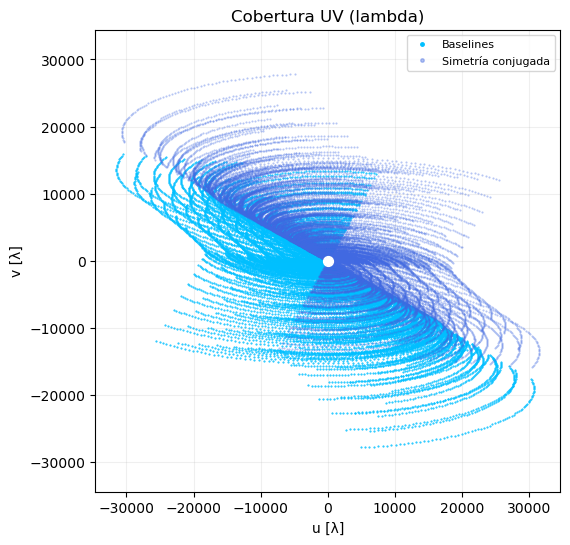

In [48]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "Sirius",
  "utc_start": "2024-10-21T00:00:00",
  "utc_end": "2024-10-21T06:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 100,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V, uvw, uvw_lambda, frequencies, baselines_enu = visibilities_simulation(VLA_L_4)

plot_uv_coverage(uvw, unit='lambda', is_lambda=True)

## Simulacion ALMA Banda 

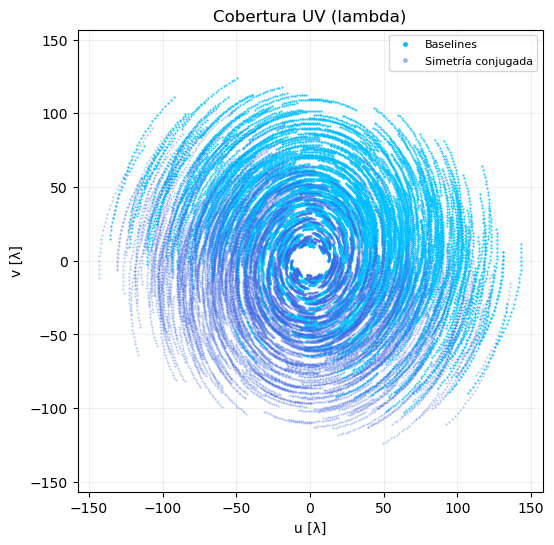

In [47]:
# simulate visibilities no grid
ALMA_1 = {
  "latitude": -23.0235,
  "longitude": 67.7539,
  "file_route": "../antenna_arrays/alma.cycle10.1.cfg",
  "catalog_source": "LMC",
  "utc_start": "2002-10-05T00:00:00",
  "utc_end": "2002-10-05T02:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "ALMA",
    "band_name": "Band 1" },
  "n_sources": 14,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V, uvw, uvw_lambda, frequencies, baselines_enu = visibilities_simulation(ALMA_1)

plot_uv_coverage(uvw, unit='lambda', show_symmetry=True, is_lambda=True)